<a href="https://colab.research.google.com/github/NamunaRegmi/AI_ML/blob/main/Tutorial7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

## 4. Denoising Autoencoder: Adding Noise

To create a denoising autoencoder, we'll add some random noise to our training and test images. The autoencoder will then learn to remove this noise during reconstruction.

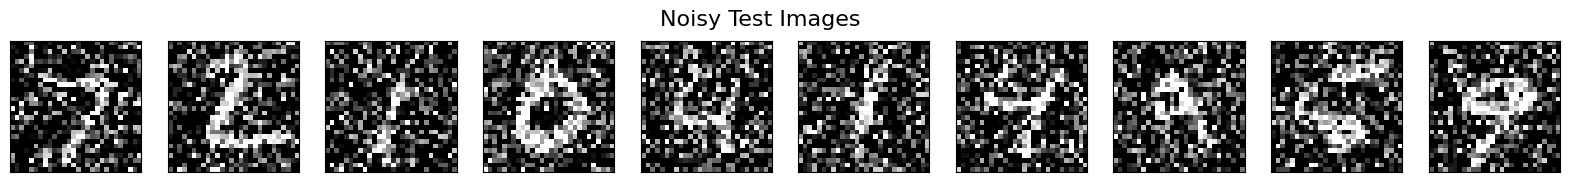

In [9]:
# Define noise parameters
noise_factor = 0.5

# Add noise to the training data
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# Add noise to the test data
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize some noisy images
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle('Noisy Test Images', fontsize=16)
plt.show()

## 1. Define the Autoencoder Architecture

We'll build a simple convolutional autoencoder. The encoder will compress the input image into a latent space representation, and the decoder will reconstruct the image from this representation.

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Input image dimensions
input_img = Input(shape=(28, 28, 1))

# --- Encoder ---
# 28x28x1 -> 14x14x16
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
# 14x14x16 -> 7x7x8 (latent space representation)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# --- Decoder ---
# From 7x7x8 to 14x14x8
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
# From 14x14x8 to 28x28x16
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
# From 28x28x16 to 28x28x1 (output image)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Compile and Train the Autoencoder

We'll compile the model using the Adam optimizer and binary crossentropy as the loss function, suitable for image reconstruction tasks where pixel values are normalized between 0 and 1. Then, we'll train it on the MNIST training data.

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step - loss: 0.2201 - val_loss: 0.1063
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 166ms/step - loss: 0.0966 - val_loss: 0.0894
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 174ms/step - loss: 0.0877 - val_loss: 0.0846
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - loss: 0.0841 - val_loss: 0.0819
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - loss: 0.0819 - val_loss: 0.0801
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 163ms/step - loss: 0.0803 - val_loss: 0.0788
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - loss: 0.0792 - val_loss: 0.0779
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 159ms/step - loss: 0.0783 - val_loss: 0.0771
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - loss: 0.0775 - val_loss: 0.0763
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - loss: 0.0768 - val_loss: 0.0758


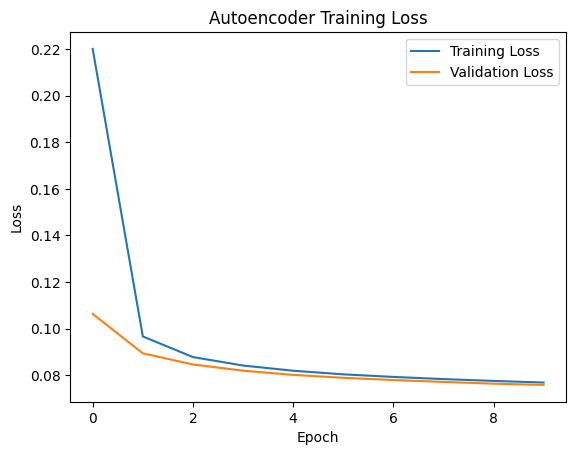

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
history = autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 3. Visualize Reconstructions

Now, let's use the trained autoencoder to reconstruct some images from the test set and visualize how well it performs.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


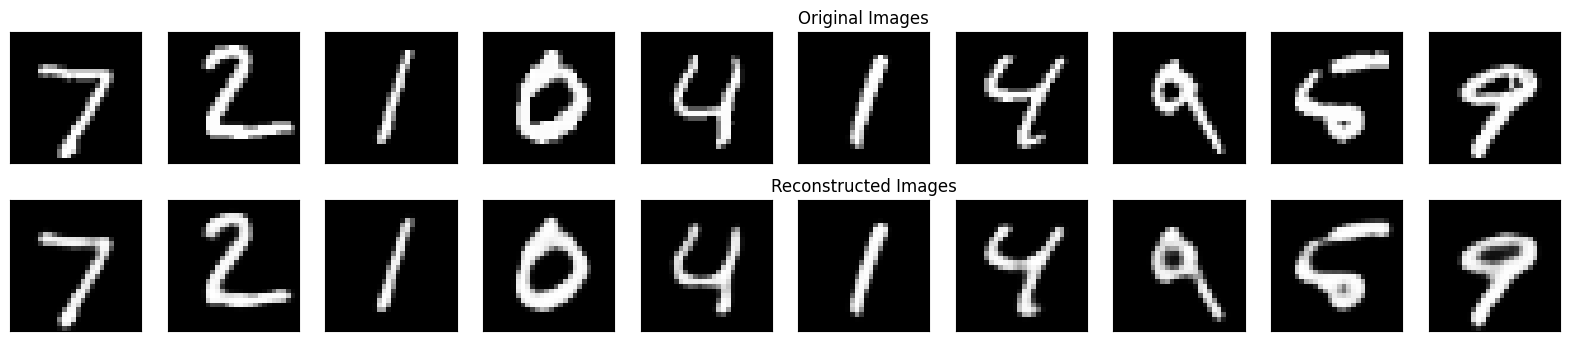

In [7]:
decoded_imgs = autoencoder.predict(x_test)

n = 10  # How many digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Original Images')

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Reconstructed Images')
plt.show()